# Dota 2 Friend Tracker — Exploration Notebook

Run top-to-bottom with an active internet connection. Responses are cached in `notebook_cache/` so re-runs don't hammer the API.

**Friends tracked:** Sherry · Haseeb · Abidi · Rafay · ABT

## 1 · Setup & Config

In [25]:
import json, pickle, time, statistics
from pathlib import Path

import httpx
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import numpy as np

plt.rcParams.update({
    'figure.facecolor': '#0d1117',
    'axes.facecolor':   '#161b22',
    'axes.edgecolor':   '#30363d',
    'axes.labelcolor':  '#e6edf3',
    'xtick.color':      '#8b949e',
    'ytick.color':      '#8b949e',
    'text.color':       '#e6edf3',
    'grid.color':       '#21262d',
    'grid.linestyle':   '--',
    'figure.dpi':       120,
})
GOLD    = '#c89b3c'
GREEN   = '#3fb950'
RED     = '#f85149'
BLUE    = '#4d9de0'
PURPLE  = '#9b5de5'
ORANGE  = '#e0854d'
PALETTE = [GOLD, GREEN, RED, BLUE, PURPLE]
ROLE_NAMES = {1: 'Carry', 2: 'Mid', 3: 'Offlane', 4: 'Jungle', 5: 'Support'}

BASE_URL = 'https://api.opendota.com/api'
FRIENDS_FILE = Path('friends.json')
CACHE_DIR = Path('notebook_cache')
CACHE_DIR.mkdir(exist_ok=True)

with open(FRIENDS_FILE) as fh:
    FRIENDS = json.load(fh)['friends']

print('Friends loaded:')
for f in FRIENDS:
    print(f"  {f['label']:8s}  account_id={f['account_id']}")

Friends loaded:
  Sherry    account_id=185602862
  Haseeb    account_id=105774679
  Abidi     account_id=97129625
  Rafay     account_id=135953784
  ABT       account_id=124437009
  Cancer    account_id=1234


## 2 · Data Fetching

In [26]:
HEADERS = {'User-Agent': 'DotaTracker-Notebook/1.0'}

def _cache_key(path: str) -> str:
    return path.replace('/', '_').strip('_')

def api_get(path: str, force: bool = False):
    key = _cache_key(path)
    cache_file = CACHE_DIR / f"{key}.pkl"
    if cache_file.exists() and not force:
        with open(cache_file, 'rb') as fh:
            return pickle.load(fh)
    resp = httpx.get(f'{BASE_URL}{path}', headers=HEADERS, timeout=20)
    resp.raise_for_status()
    data = resp.json()
    with open(cache_file, 'wb') as fh:
        pickle.dump(data, fh)
    time.sleep(0.4)
    return data

def fetch_all(force: bool = False):
    result = {}
    for f in FRIENDS:
        aid = f['account_id']
        print(f"Fetching {f['label']}...", end=' ')
        profile = api_get(f'/players/{aid}', force)
        wl      = api_get(f'/players/{aid}/wl', force)
        recent  = api_get(f'/players/{aid}/recentMatches', force)
        heroes  = api_get(f'/players/{aid}/heroes', force)
        peers   = api_get(f'/players/{aid}/peers', force)
        totals  = api_get(f'/players/{aid}/totals', force)
        for m in recent:
            is_rad = m.get('player_slot', 0) < 128
            m['won'] = m['radiant_win'] if is_rad else not m['radiant_win']
            m['kda'] = round((m['kills'] + m['assists']) / max(m['deaths'], 1), 2)
            dur = max(m.get('duration', 1), 1)
            m['dmg_per_min']  = round(m.get('hero_damage', 0) / dur * 60, 1)
            m['lh_per_min']   = round(m.get('last_hits', 0)   / dur * 60, 2)
        result[aid] = {'label': f['label'], 'profile': profile, 'wl': wl,
                       'recent': recent, 'heroes': heroes, 'peers': peers, 'totals': totals}
        print('done')
    return result

hero_ref = api_get('/heroes')
HERO_NAMES = {h['id']: h['localized_name'] for h in hero_ref}

D = fetch_all()
print('\nAll data loaded.')

Fetching Sherry... done
Fetching Haseeb... done
Fetching Abidi... done
Fetching Rafay... done
Fetching ABT... done
Fetching Cancer... done

All data loaded.


## 2b · Deep Match Cache (200 matches per player)

Fetches the last 200 matches per player using two OpenDota endpoints:
1. `/players/{id}/matches?limit=200` → ordered match list (basic stats + match IDs)
2. `/matches/{match_id}` → full per-match stats (hero damage, wards, buybacks, etc.)

**Caching rules:**
- Per-player match lists are cached in `data/match_cache/player_match_ids/`
- Full match JSON is cached in `data/match_cache/matches/{match_id}.json`
- Match files are **permanent** — once saved they are never re-fetched
- Shared across players: if Haseeb & Abidi played together the match is fetched once

**First run:** ~600–900 API calls, ~5 min. Re-runs are instant.
**CLI equivalent:** `python cli.py refresh-matches [--limit 200] [--force]`

In [ ]:
MATCH_CACHE_DIR = Path('data/match_cache')
PLAYER_IDS_DIR  = MATCH_CACHE_DIR / 'player_match_ids'
MATCHES_DIR     = MATCH_CACHE_DIR / 'matches'
for _d in [MATCH_CACHE_DIR, PLAYER_IDS_DIR, MATCHES_DIR]:
    _d.mkdir(parents=True, exist_ok=True)

MATCH_LIMIT = 200

# ── Fetch helpers ─────────────────────────────────────────────────────────────

def _raw_get(url: str) -> dict | list:
    """Direct HTTP GET with polite delay. No pickle caching — we manage our own."""
    resp = httpx.get(url, headers=HEADERS, timeout=30)
    resp.raise_for_status()
    time.sleep(0.35)
    return resp.json()

def fetch_player_match_list(account_id: int, force: bool = False) -> list[dict]:
    """Fetch /players/{id}/matches?limit=MATCH_LIMIT. Cached per player as JSON."""
    cache_file = PLAYER_IDS_DIR / f'{account_id}.json'
    if cache_file.exists() and not force:
        return json.loads(cache_file.read_text())
    data = _raw_get(
        f'{BASE_URL}/players/{account_id}/matches?limit={MATCH_LIMIT}&significant=1'
    )
    cache_file.write_text(json.dumps(data))
    return data

def fetch_full_match(match_id: int) -> dict | None:
    """
    Fetch /matches/{match_id}. Skips entirely if already cached.
    Returns None on error (private match, 404, rate-limit, etc.).
    """
    match_file = MATCHES_DIR / f'{match_id}.json'
    if match_file.exists():
        return json.loads(match_file.read_text())
    try:
        resp = httpx.get(f'{BASE_URL}/matches/{match_id}', headers=HEADERS, timeout=30)
        resp.raise_for_status()
        match_file.write_text(resp.text)
        time.sleep(0.35)
        return resp.json()
    except Exception as exc:
        print(f'  [warn] {match_id}: {exc}')
        return None

def extract_player_stats(match: dict, account_id: int) -> dict | None:
    """Extract one player's flat stats row from a full match dict."""
    for p in match.get('players', []):
        if p.get('account_id') != account_id:
            continue
        is_rad = p.get('player_slot', 0) < 128
        won    = match.get('radiant_win', False) if is_rad else not match.get('radiant_win', False)
        dur    = max(match.get('duration', 1), 1)
        k, d, a = p.get('kills', 0), p.get('deaths', 0), p.get('assists', 0)
        return {
            'match_id':        match['match_id'],
            'hero_id':         p.get('hero_id'),
            'kills':           k,
            'deaths':          d,
            'assists':         a,
            'gold_per_min':    p.get('gold_per_min', 0),
            'xp_per_min':      p.get('xp_per_min', 0),
            'last_hits':       p.get('last_hits', 0),
            'denies':          p.get('denies', 0),
            'hero_damage':     p.get('hero_damage', 0),
            'tower_damage':    p.get('tower_damage', 0),
            'hero_healing':    p.get('hero_healing', 0),
            'obs_placed':      p.get('obs_placed', 0),
            'sen_placed':      p.get('sen_placed', 0),
            'buyback_count':   p.get('buyback_count', 0),
            'net_worth':       p.get('net_worth', 0),
            'actions_per_min': p.get('actions_per_min', 0),
            'lane_role':       p.get('lane_role'),
            'is_roaming':      p.get('is_roaming', False),
            'duration':        dur,
            'won':             won,
            'kda':             round((k + a) / max(d, 1), 2),
            'dmg_per_min':     round(p.get('hero_damage', 0) / dur * 60, 1),
            'lh_per_min':      round(p.get('last_hits', 0)  / dur * 60, 2),
        }
    return None

# ── Step 1: Fetch per-player match ID lists ───────────────────────────────────
print(f'Fetching last {MATCH_LIMIT} match IDs per player...')
MATCH_LISTS = {}
for f in FRIENDS:
    aid    = f['account_id']
    cached = (PLAYER_IDS_DIR / f'{aid}.json').exists()
    print(f"  {f['label']:8s}", end='  ')
    ml = fetch_player_match_list(aid)
    MATCH_LISTS[aid] = ml
    print(f'{len(ml)} matches  {"(cached)" if cached else "(fetched)"}')

# ── Step 2: Identify uncached match IDs ──────────────────────────────────────
all_ids    = {m['match_id'] for ml in MATCH_LISTS.values() for m in ml}
cached_ids = {int(f.stem) for f in MATCHES_DIR.iterdir() if f.suffix == '.json'}
to_fetch   = sorted(all_ids - cached_ids)

print(f'\n{len(all_ids)} unique matches across all players')
print(f'{len(cached_ids & all_ids)} already cached, {len(to_fetch)} to fetch '
      f'(~{len(to_fetch) * 0.35 / 60:.0f} min)')

# ── Step 3: Fetch uncached full matches ───────────────────────────────────────
if to_fetch:
    errors = 0
    for i, mid in enumerate(to_fetch):
        if i % 50 == 0:
            pct = i / len(to_fetch) * 100
            print(f'  [{i:4d}/{len(to_fetch)}]  {pct:.0f}%  errors={errors}', flush=True)
        if fetch_full_match(mid) is None:
            errors += 1
    print(f'\nFetch complete — {len(to_fetch) - errors} ok, {errors} errors.')

total = len(list(MATCHES_DIR.iterdir()))
print(f'Cache total: {total} match files')

# ── Step 4: Build DEEP dict — per-player list of 200-match stat rows ──────────
print('\nBuilding DEEP match history...')
DEEP: dict[int, list[dict]] = {}
for f in FRIENDS:
    aid   = f['account_id']
    rows  = []
    for m_basic in MATCH_LISTS.get(aid, []):
        m_full = fetch_full_match(m_basic['match_id'])  # instant from cache
        if m_full is None:
            continue
        row = extract_player_stats(m_full, aid)
        if row:
            rows.append(row)
    DEEP[aid] = rows
    wr = sum(1 for r in rows if r['won']) / len(rows) * 100 if rows else 0
    print(f"  {f['label']:8s}  {len(rows)} matches  {wr:.1f}% WR")

print('\nDEEP ready — use DEEP[account_id] for 200-match analysis.')

## 3 · Winrate Overview

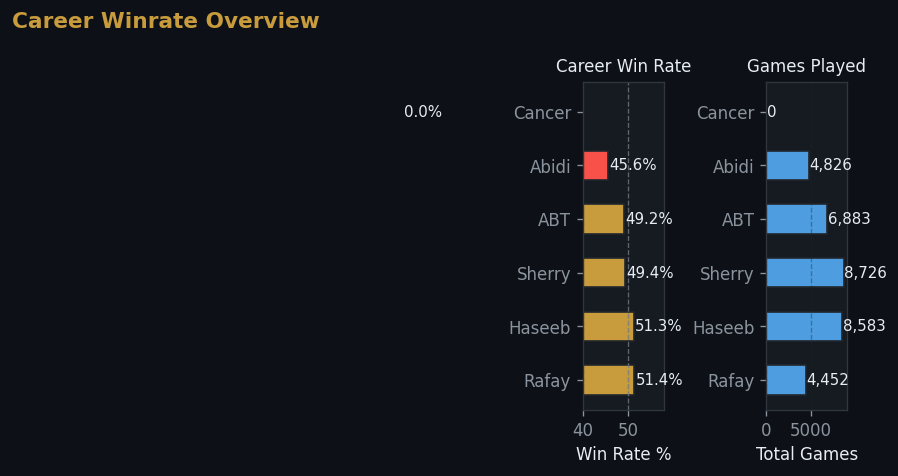

 Label  Wins  Losses  Total  WR%     Rank
 Rafay  2288    2164   4452 51.4  Ancient
Haseeb  4404    4179   8583 51.3   Divine
Sherry  4308    4418   8726 49.4   Archon
   ABT  3386    3497   6883 49.2   Archon
 Abidi  2199    2627   4826 45.6 Guardian
Cancer     0       0      0  0.0 Unranked


In [27]:
rows = []
for aid, d in D.items():
    wins   = d['wl']['win']
    losses = d['wl']['lose']
    total  = wins + losses
    wr     = round(wins / total * 100, 1) if total else 0
    rt     = d['profile'].get('rank_tier')
    medal  = {1:'Herald',2:'Guardian',3:'Crusader',4:'Archon',5:'Legend',6:'Ancient',7:'Divine',8:'Immortal'}.get(rt//10 if rt else 0, 'Unranked')
    rows.append({'Label': d['label'], 'Wins': wins, 'Losses': losses, 'Total': total, 'WR%': wr, 'Rank': medal})

df_wl = pd.DataFrame(rows).sort_values('WR%', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Career Winrate Overview', color=GOLD, fontsize=13, fontweight='bold')

ax = axes[0]
colors = [GREEN if w >= 52 else GOLD if w >= 48 else RED for w in df_wl['WR%']]
bars = ax.barh(df_wl['Label'], df_wl['WR%'], color=colors, edgecolor='#21262d', height=0.55)
ax.axvline(50, color='#8b949e', linestyle='--', linewidth=0.8, alpha=0.6)
for bar, val in zip(bars, df_wl['WR%']):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2, f'{val}%', va='center', fontsize=9)
ax.set_xlim(40, 58); ax.set_xlabel('Win Rate %'); ax.set_title('Career Win Rate', fontsize=10); ax.grid(axis='x', alpha=0.4)

ax2 = axes[1]
ax2.barh(df_wl['Label'], df_wl['Total'], color=BLUE, edgecolor='#21262d', height=0.55)
for bar, val in zip(ax2.patches, df_wl['Total']):
    ax2.text(bar.get_width() + 30, bar.get_y() + bar.get_height()/2, f'{val:,}', va='center', fontsize=9)
ax2.set_xlabel('Total Games'); ax2.set_title('Games Played', fontsize=10); ax2.grid(axis='x', alpha=0.4)

plt.tight_layout()
plt.savefig('notebook_cache/winrate_overview.png', bbox_inches='tight', facecolor='#0d1117')
plt.show()
print(df_wl[['Label','Wins','Losses','Total','WR%','Rank']].to_string(index=False))

## 4 · KDA Trend (last 20 matches)

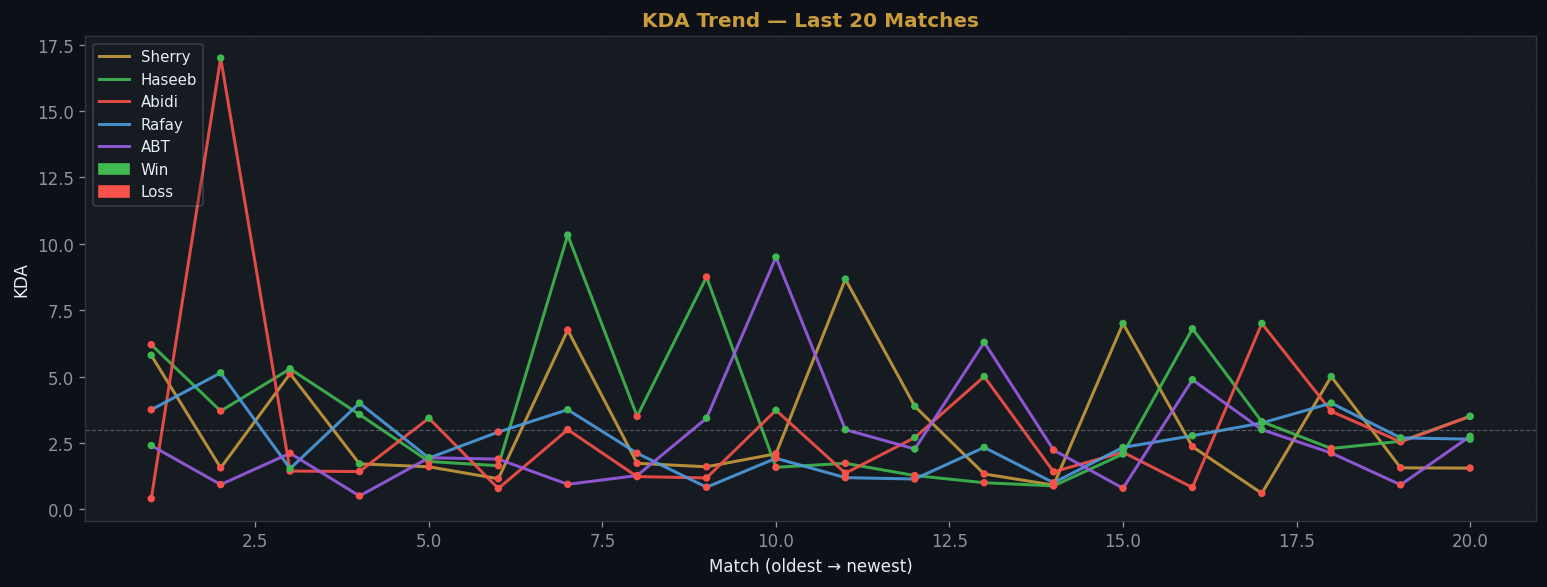

In [28]:
fig, ax = plt.subplots(figsize=(13, 5))
fig.patch.set_facecolor('#0d1117')

for (aid, d), color in zip(D.items(), PALETTE):
    matches = list(reversed(d['recent'][:20]))
    kdas = [m['kda'] for m in matches]
    x = range(1, len(kdas)+1)
    ax.plot(x, kdas, color=color, linewidth=1.8, label=d['label'], alpha=0.9)
    ax.scatter(x, kdas, color=[GREEN if m['won'] else RED for m in matches], s=20, zorder=5, edgecolors='none')

ax.axhline(3.0, color='#8b949e', linestyle='--', linewidth=0.7, alpha=0.5)
ax.set_xlabel('Match (oldest → newest)'); ax.set_ylabel('KDA')
ax.set_title('KDA Trend — Last 20 Matches', color=GOLD, fontsize=12, fontweight='bold')
ax.grid(alpha=0.3)
win_patch  = mpatches.Patch(color=GREEN, label='Win')
loss_patch = mpatches.Patch(color=RED,   label='Loss')
ax.legend(handles=ax.get_legend_handles_labels()[0] + [win_patch, loss_patch],
          labels =ax.get_legend_handles_labels()[1] + ['Win', 'Loss'],
          loc='upper left', framealpha=0.2, fontsize=9)
plt.tight_layout()
plt.savefig('notebook_cache/kda_trend.png', bbox_inches='tight', facecolor='#0d1117')
plt.show()

## 5 · Hero Heatmap (top 10 heroes × friends, colour = winrate)

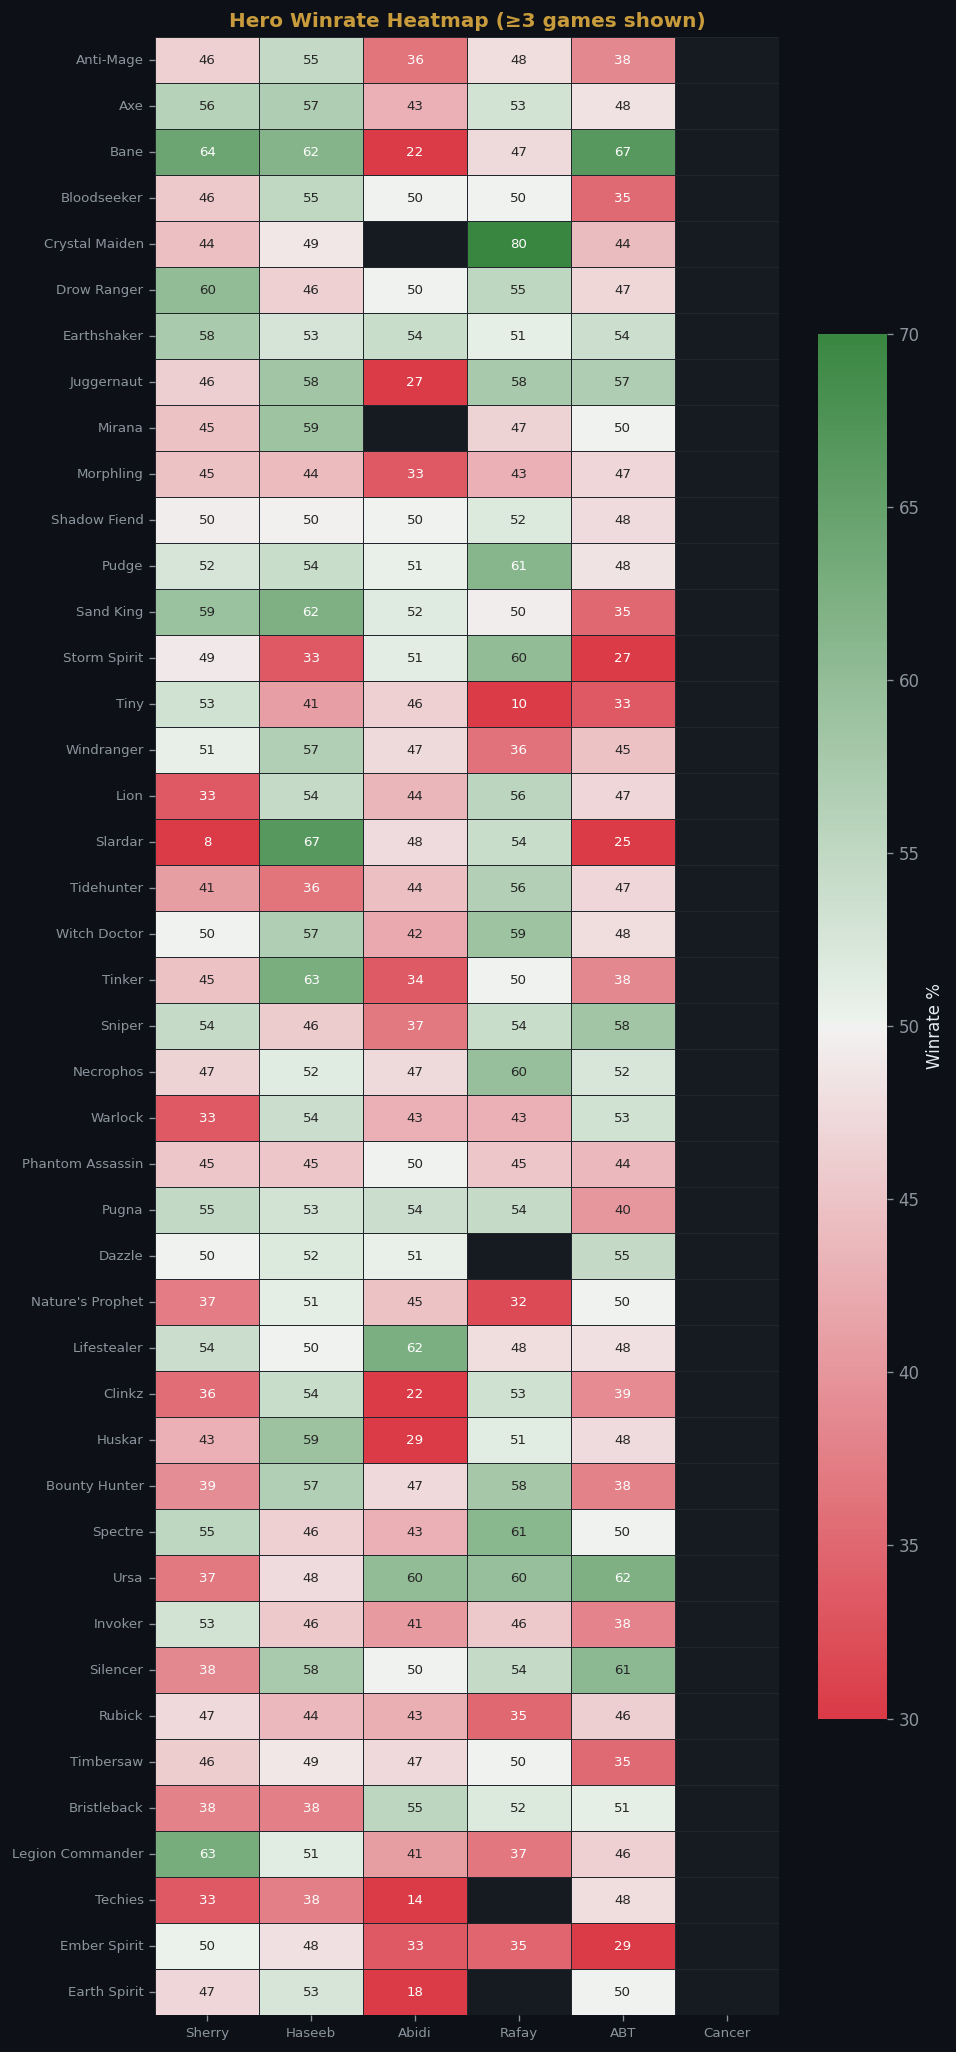

In [29]:
all_top = set()
for d in D.values():
    top = sorted(d['heroes'], key=lambda h: h['games'], reverse=True)[:10]
    all_top.update(h['hero_id'] for h in top)

top_heroes = sorted(all_top)
labels_f = [d['label'] for d in D.values()]
labels_h = [HERO_NAMES.get(hid, f'Hero {hid}') for hid in top_heroes]

matrix = np.full((len(top_heroes), len(labels_f)), np.nan)
for col_i, (aid, d) in enumerate(D.items()):
    hero_map = {h['hero_id']: h for h in d['heroes']}
    for row_i, hid in enumerate(top_heroes):
        h = hero_map.get(hid)
        if h and h['games'] >= 3:
            matrix[row_i, col_i] = round(h['win'] / h['games'] * 100, 1)

df_heat = pd.DataFrame(matrix, index=labels_h, columns=labels_f)

fig, ax = plt.subplots(figsize=(8, max(6, len(top_heroes) * 0.4)))
fig.patch.set_facecolor('#0d1117')
cmap = sns.diverging_palette(10, 130, as_cmap=True)
sns.heatmap(df_heat, ax=ax, cmap=cmap, center=50, vmin=30, vmax=70,
            annot=True, fmt='.0f', linewidths=0.4, linecolor='#21262d',
            cbar_kws={'label': 'Winrate %', 'shrink': 0.7}, annot_kws={'size': 8})
ax.set_title('Hero Winrate Heatmap (≥3 games shown)', color=GOLD, fontsize=12, fontweight='bold')
ax.tick_params(axis='both', labelsize=8)
plt.tight_layout()
plt.savefig('notebook_cache/hero_heatmap.png', bbox_inches='tight', facecolor='#0d1117')
plt.show()

## 6 · GPM / XPM Scatter (coloured by win/loss)

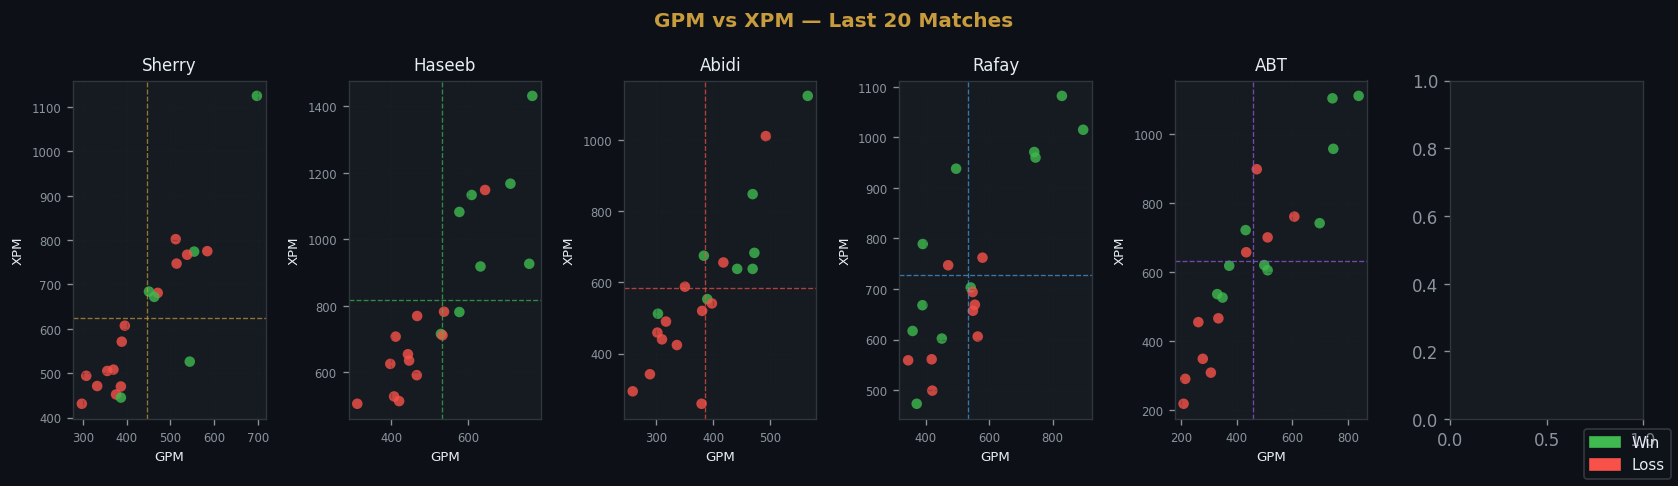

In [30]:
fig, axes = plt.subplots(1, len(D), figsize=(14, 4), sharey=False)
fig.suptitle('GPM vs XPM — Last 20 Matches', color=GOLD, fontsize=12, fontweight='bold')

for ax, (aid, d), col in zip(axes, D.items(), PALETTE):
    matches = d['recent'][:20]
    gpms = [m['gold_per_min'] for m in matches]
    xpms = [m['xp_per_min']   for m in matches]
    colors = [GREEN if m['won'] else RED for m in matches]
    ax.scatter(gpms, xpms, c=colors, s=40, alpha=0.8, edgecolors='none')
    ax.axvline(np.mean(gpms), color=col, linewidth=0.8, linestyle='--', alpha=0.7)
    ax.axhline(np.mean(xpms), color=col, linewidth=0.8, linestyle='--', alpha=0.7)
    ax.set_title(d['label'], fontsize=10); ax.set_xlabel('GPM', fontsize=8); ax.set_ylabel('XPM', fontsize=8)
    ax.tick_params(labelsize=7); ax.grid(alpha=0.25)

fig.legend(handles=[mpatches.Patch(color=GREEN, label='Win'), mpatches.Patch(color=RED, label='Loss')],
           loc='lower right', framealpha=0.2, fontsize=9)
plt.tight_layout()
plt.savefig('notebook_cache/gpm_xpm_scatter.png', bbox_inches='tight', facecolor='#0d1117')
plt.show()

## 7 · Recent Form (sparkline-style W/L sequence)

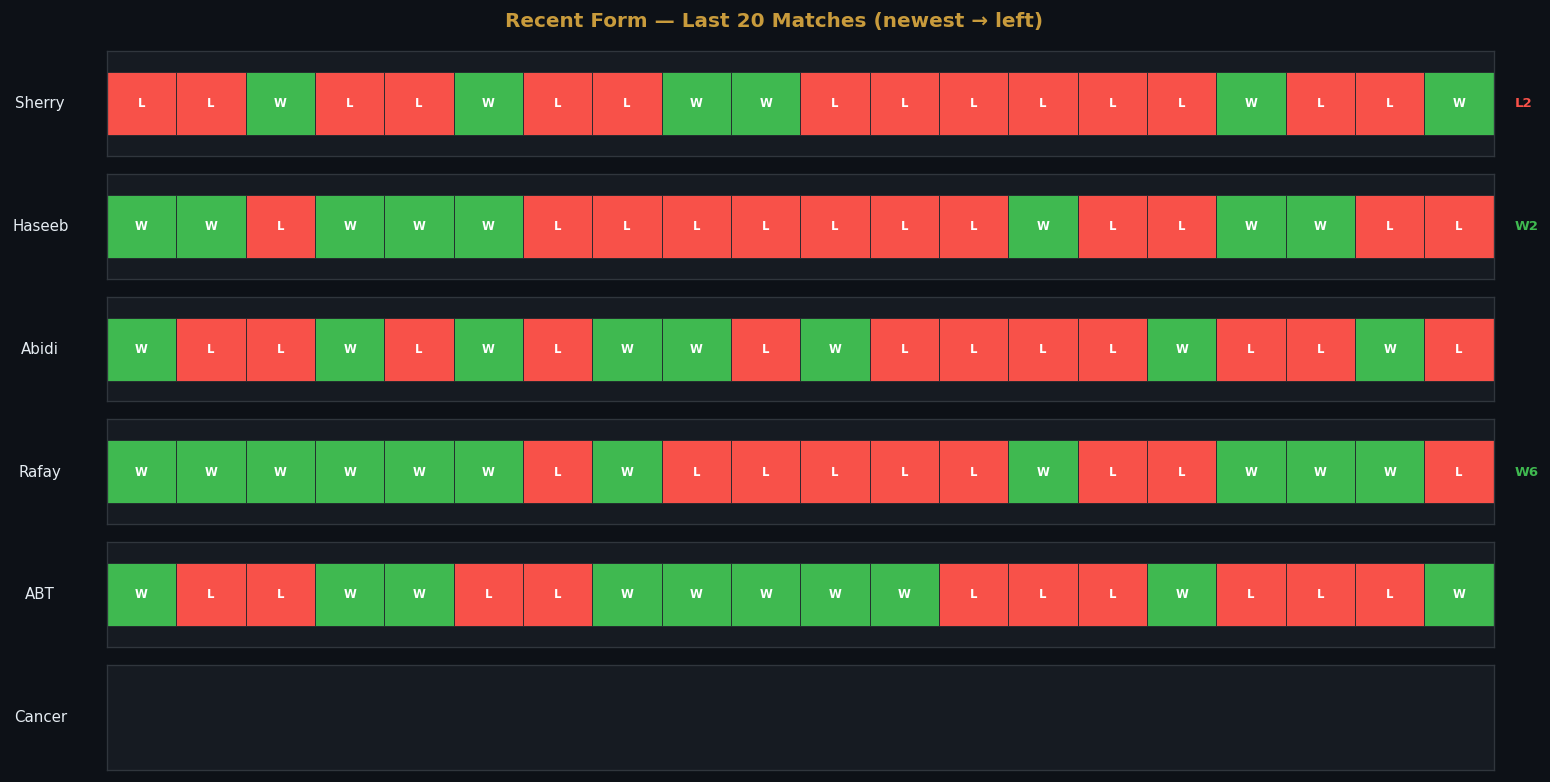

In [31]:
n_players = len(D)
fig, axes = plt.subplots(n_players, 1, figsize=(13, n_players * 1.1))
fig.suptitle('Recent Form — Last 20 Matches (newest → left)', color=GOLD, fontsize=12, fontweight='bold')
if n_players == 1: axes = [axes]

for ax, (aid, d) in zip(axes, D.items()):
    matches = d['recent'][:20]
    for i, m in enumerate(matches):
        col = GREEN if m['won'] else RED
        ax.barh(0, 1, left=i, height=0.6, color=col, edgecolor='#21262d', linewidth=0.5)
        ax.text(i + 0.5, 0, 'W' if m['won'] else 'L', ha='center', va='center', fontsize=7, color='white', fontweight='bold')
    ax.set_xlim(0, 20); ax.set_ylim(-0.5, 0.5); ax.set_yticks([]); ax.set_xticks([])
    ax.set_ylabel(d['label'], rotation=0, labelpad=40, va='center', fontsize=9)
    streak, first_won = 0, matches[0]['won'] if matches else None
    for m in matches:
        if m['won'] == first_won: streak += 1
        else: break
    if streak >= 2:
        ax.text(20.3, 0, f"{'W' if first_won else 'L'}{streak}", va='center', fontsize=8,
                color=GREEN if first_won else RED, fontweight='bold')

plt.tight_layout()
plt.savefig('notebook_cache/recent_form.png', bbox_inches='tight', facecolor='#0d1117')
plt.show()

## 8 · Group Synergy Matrix

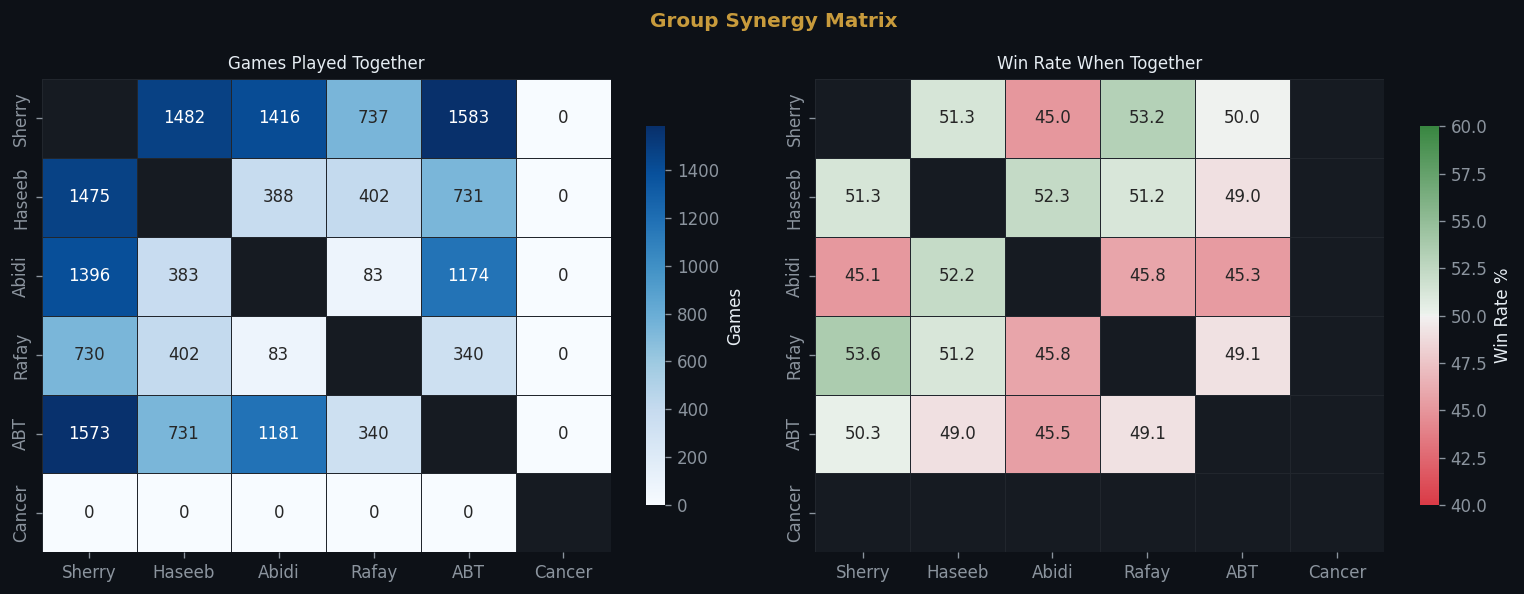


Games Together:
        Sherry  Haseeb   Abidi  Rafay     ABT  Cancer
Sherry     NaN  1482.0  1416.0  737.0  1583.0     0.0
Haseeb  1475.0     NaN   388.0  402.0   731.0     0.0
Abidi   1396.0   383.0     NaN   83.0  1174.0     0.0
Rafay    730.0   402.0    83.0    NaN   340.0     0.0
ABT     1573.0   731.0  1181.0  340.0     NaN     0.0
Cancer     0.0     0.0     0.0    0.0     0.0     NaN

Win Rate Together (%):
        Sherry  Haseeb  Abidi  Rafay   ABT  Cancer
Sherry     NaN    51.3   45.0   53.2  50.0     NaN
Haseeb    51.3     NaN   52.3   51.2  49.0     NaN
Abidi     45.1    52.2    NaN   45.8  45.3     NaN
Rafay     53.6    51.2   45.8    NaN  49.1     NaN
ABT       50.3    49.0   45.5   49.1   NaN     NaN
Cancer     NaN     NaN    NaN    NaN   NaN     NaN


In [32]:
friend_ids   = [f['account_id'] for f in FRIENDS]
friend_names = [f['label']       for f in FRIENDS]
n = len(friend_ids)
games_mat = np.zeros((n, n))
wr_mat    = np.full((n, n), np.nan)

for i, aid in enumerate(friend_ids):
    peer_map = {p['account_id']: p for p in D[aid]['peers']}
    for j, other_id in enumerate(friend_ids):
        if i == j: continue
        p = peer_map.get(other_id)
        if p and p.get('with_games', 0) > 0:
            g, w = p['with_games'], p['with_win']
            games_mat[i, j] = g
            wr_mat[i, j]    = round(w / g * 100, 1)

# Fill diagonal on the numpy arrays BEFORE creating DataFrames.
# pandas 2.x returns a read-only view from .values, so np.fill_diagonal
# on df.values raises ValueError: underlying array is read-only.
np.fill_diagonal(games_mat, np.nan)
# wr_mat diagonal is already NaN (initialized with np.full(..., np.nan))

df_games = pd.DataFrame(games_mat, index=friend_names, columns=friend_names)
df_wr    = pd.DataFrame(wr_mat,    index=friend_names, columns=friend_names)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Group Synergy Matrix', color=GOLD, fontsize=12, fontweight='bold')

sns.heatmap(df_games, ax=axes[0], cmap='Blues', annot=True, fmt='.0f',
            linewidths=0.4, linecolor='#21262d',
            cbar_kws={'label': 'Games', 'shrink': 0.8}, annot_kws={'size': 10})
axes[0].set_title('Games Played Together', fontsize=10)

sns.heatmap(df_wr, ax=axes[1], cmap=sns.diverging_palette(10, 130, as_cmap=True),
            center=50, vmin=40, vmax=60,
            annot=True, fmt='.1f', linewidths=0.4, linecolor='#21262d',
            cbar_kws={'label': 'Win Rate %', 'shrink': 0.8}, annot_kws={'size': 10})
axes[1].set_title('Win Rate When Together', fontsize=10)

for ax_ in axes: ax_.set_xlabel(''); ax_.set_ylabel('')
plt.tight_layout()
plt.savefig('notebook_cache/group_synergy.png', bbox_inches='tight', facecolor='#0d1117')
plt.show()
print('\nGames Together:'); print(df_games.to_string())
print('\nWin Rate Together (%):'); print(df_wr.to_string())

## 9 · Pipeline Diagram

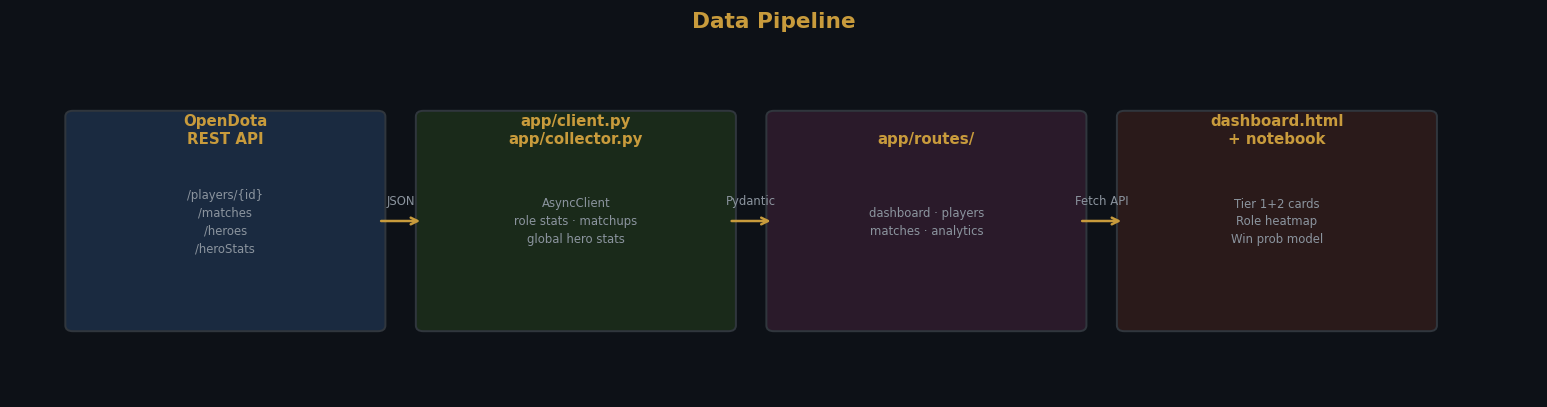

In [33]:
fig, ax = plt.subplots(figsize=(13, 3.5))
fig.patch.set_facecolor('#0d1117'); ax.set_facecolor('#0d1117')
ax.set_xlim(0, 10); ax.set_ylim(0, 3); ax.axis('off')
ax.set_title('Data Pipeline', color=GOLD, fontsize=13, fontweight='bold', pad=12)

boxes = [
    (0.4, 'OpenDota\nREST API',   '/players/{id}\n/matches\n/heroes\n/heroStats', '#1a2a40'),
    (2.7, 'app/client.py\napp/collector.py', 'AsyncClient\nrole stats · matchups\nglobal hero stats', '#1a2a1a'),
    (5.0, 'app/routes/',          'dashboard · players\nmatches · analytics', '#2a1a2a'),
    (7.3, 'dashboard.html\n+ notebook', 'Tier 1+2 cards\nRole heatmap\nWin prob model', '#2a1a1a'),
]

for x, title, body, bg in boxes:
    rect = mpatches.FancyBboxPatch((x, 0.6), 2.0, 1.8, boxstyle='round,pad=0.05', facecolor=bg, edgecolor='#30363d', linewidth=1.2)
    ax.add_patch(rect)
    ax.text(x+1.0, 2.15, title, ha='center', va='bottom', fontsize=9, fontweight='bold', color=GOLD)
    ax.text(x+1.0, 1.5,  body,  ha='center', va='center', fontsize=7, color='#8b949e', linespacing=1.5)

for x_start in [2.4, 4.7, 7.0]:
    ax.annotate('', xy=(x_start+0.3, 1.5), xytext=(x_start, 1.5),
                arrowprops=dict(arrowstyle='->', color=GOLD, lw=1.5))

ax.text(2.55, 1.65, 'JSON',     fontsize=7, color='#8b949e', ha='center')
ax.text(4.85, 1.65, 'Pydantic', fontsize=7, color='#8b949e', ha='center')
ax.text(7.15, 1.65, 'Fetch API',fontsize=7, color='#8b949e', ha='center')

plt.tight_layout()
plt.savefig('notebook_cache/pipeline_diagram.png', bbox_inches='tight', facecolor='#0d1117')
plt.show()

---
## Tier 2 Stats
Sections 10–12 use data already loaded in Section 2 — no extra API calls needed.

## 10 · Damage & Last Hits per Minute

 Label  DMG/min  LH/min  Twr DMG
Haseeb    867.9    5.09   4160.0
 Rafay    719.7    5.17   3231.0
Sherry    600.4    4.57   3266.0
   ABT    571.9    4.72   3115.0
 Abidi    499.6    2.86    578.0


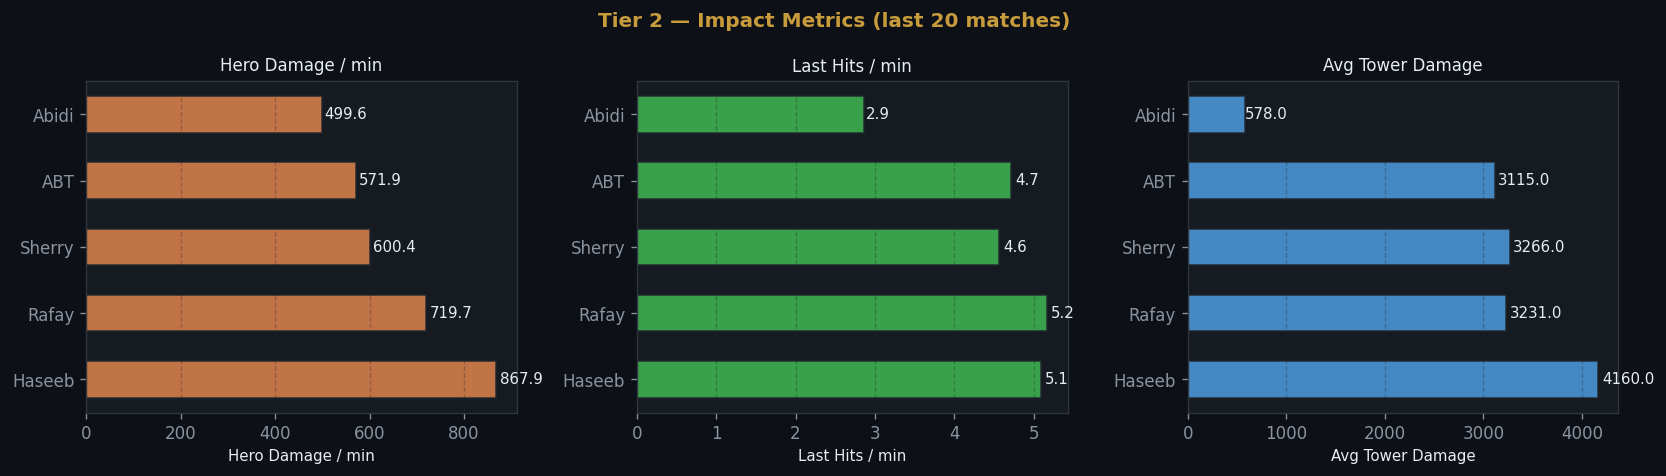

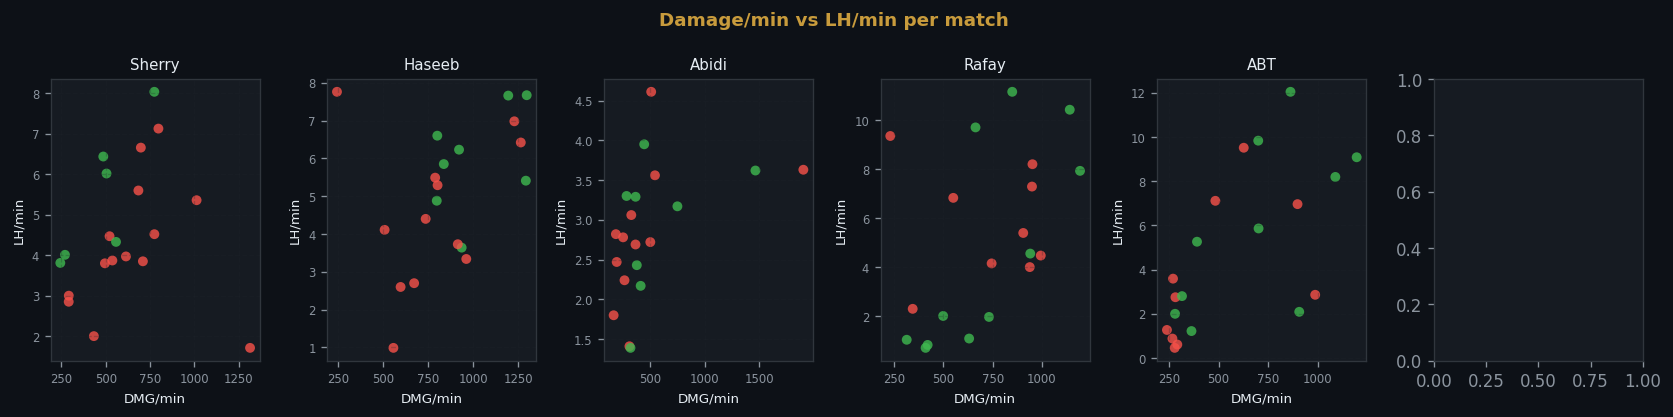

In [34]:
# Build per-player summary of Tier 2 impact metrics
t2_rows = []
for aid, d in D.items():
    ms = d['recent'][:20]
    n  = len(ms)
    if n == 0: continue
    t2_rows.append({
        'Label':     d['label'],
        'DMG/min':   round(sum(m['dmg_per_min'] for m in ms) / n, 1),
        'LH/min':    round(sum(m['lh_per_min']  for m in ms) / n, 2),
        'Twr DMG':   round(sum(m.get('tower_damage', 0) for m in ms) / n, 0),
    })

df_t2 = pd.DataFrame(t2_rows).sort_values('DMG/min', ascending=False)
print(df_t2.to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle('Tier 2 — Impact Metrics (last 20 matches)', color=GOLD, fontsize=12, fontweight='bold')

for ax, col, color, label in [
    (axes[0], 'DMG/min', ORANGE, 'Hero Damage / min'),
    (axes[1], 'LH/min',  GREEN,  'Last Hits / min'),
    (axes[2], 'Twr DMG', BLUE,   'Avg Tower Damage'),
]:
    bars = ax.barh(df_t2['Label'], df_t2[col], color=color, edgecolor='#21262d', height=0.55, alpha=0.85)
    for bar, val in zip(bars, df_t2[col]):
        ax.text(bar.get_width() * 1.01, bar.get_y() + bar.get_height()/2, f'{val:.1f}', va='center', fontsize=9)
    ax.set_xlabel(label, fontsize=9); ax.set_title(label, fontsize=10); ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('notebook_cache/t2_impact_metrics.png', bbox_inches='tight', facecolor='#0d1117')
plt.show()

# Scatter: DMG/min vs LH/min coloured by win/loss per player
fig, axes = plt.subplots(1, len(D), figsize=(14, 3.5), sharey=False)
fig.suptitle('Damage/min vs LH/min per match', color=GOLD, fontsize=11, fontweight='bold')

for ax, (aid, d), col in zip(axes, D.items(), PALETTE):
    ms = d['recent'][:20]
    ax.scatter([m['dmg_per_min'] for m in ms], [m['lh_per_min'] for m in ms],
               c=[GREEN if m['won'] else RED for m in ms], s=35, alpha=0.8, edgecolors='none')
    ax.set_title(d['label'], fontsize=9); ax.set_xlabel('DMG/min', fontsize=8); ax.set_ylabel('LH/min', fontsize=8)
    ax.tick_params(labelsize=7); ax.grid(alpha=0.25)

plt.tight_layout()
plt.savefig('notebook_cache/t2_dmg_lh_scatter.png', bbox_inches='tight', facecolor='#0d1117')
plt.show()

## 11 · Role Performance (last 20 matches)

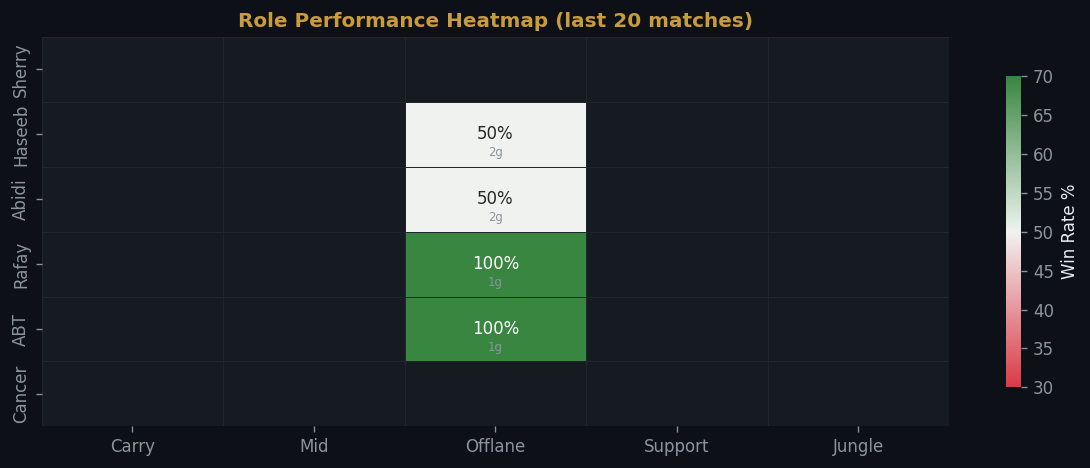


Duration Performance:
Bucket  30-45min  <30min  >45min
Label                           
ABT         40.0     NaN    60.0
Abidi       50.0     0.0    36.4
Haseeb      38.5     NaN    42.9
Rafay       53.8     NaN    57.1
Sherry      30.0     NaN    30.0


In [35]:
ROLE_ORDER = ['Carry', 'Mid', 'Offlane', 'Support', 'Jungle']

# Build role stats from recentMatches (lane_role field)
role_data = {}
for aid, d in D.items():
    label = d['label']
    buckets = {rn: {'games': 0, 'wins': 0} for rn in ROLE_NAMES.values()}
    for m in d['recent'][:20]:
        rn = ROLE_NAMES.get(m.get('lane_role'))
        if not rn: continue
        buckets[rn]['games'] += 1
        if m['won']: buckets[rn]['wins'] += 1
    role_data[label] = {
        rn: {'games': v['games'], 'winrate': round(v['wins']/v['games']*100,1) if v['games'] else np.nan}
        for rn, v in buckets.items()
    }

# Heatmap: players × roles, colour = winrate
labels_p = list(role_data.keys())
wr_matrix    = np.full((len(labels_p), len(ROLE_ORDER)), np.nan)
games_matrix = np.zeros((len(labels_p), len(ROLE_ORDER)), dtype=int)

for i, label in enumerate(labels_p):
    for j, role in enumerate(ROLE_ORDER):
        rd = role_data[label].get(role, {})
        wr_matrix[i, j]    = rd.get('winrate', np.nan)
        games_matrix[i, j] = rd.get('games', 0)

df_role_wr = pd.DataFrame(wr_matrix,    index=labels_p, columns=ROLE_ORDER)
df_role_g  = pd.DataFrame(games_matrix, index=labels_p, columns=ROLE_ORDER)

# Build annotation strings: "55%" or "—"
# .applymap was renamed to .map in pandas 2.1
annot_fn = lambda v: f'{v:.0f}%' if not np.isnan(v) else '—'
annot_df = df_role_wr.map(annot_fn)

fig, ax = plt.subplots(figsize=(10, 4))
fig.patch.set_facecolor('#0d1117')
sns.heatmap(df_role_wr, ax=ax, cmap=sns.diverging_palette(10, 130, as_cmap=True),
            center=50, vmin=30, vmax=70,
            annot=annot_df, fmt='', linewidths=0.5, linecolor='#21262d',
            cbar_kws={'label': 'Win Rate %', 'shrink': 0.8})
ax.set_title('Role Performance Heatmap (last 20 matches)', color=GOLD, fontsize=12, fontweight='bold')
ax.set_xlabel(''); ax.set_ylabel('')

# Overlay game counts in small text
for i in range(len(labels_p)):
    for j in range(len(ROLE_ORDER)):
        g = games_matrix[i, j]
        if g > 0:
            ax.text(j+0.5, i+0.78, f'{g}g', ha='center', va='center', fontsize=7, color='#8b949e')

plt.tight_layout()
plt.savefig('notebook_cache/t2_role_heatmap.png', bbox_inches='tight', facecolor='#0d1117')
plt.show()

# Duration buckets
dur_data = []
for aid, d in D.items():
    for bucket, lo, hi in [('<30min', 0, 1800), ('30-45min', 1800, 2700), ('>45min', 2700, 9999)]:
        ms = [m for m in d['recent'][:20] if lo <= m.get('duration',0) < hi]
        if not ms: continue
        wr = round(sum(1 for m in ms if m['won']) / len(ms) * 100, 1)
        dur_data.append({'Label': d['label'], 'Bucket': bucket, 'Games': len(ms), 'WR%': wr})

df_dur = pd.DataFrame(dur_data)
print('\nDuration Performance:')
print(df_dur.pivot_table(index='Label', columns='Bucket', values='WR%').to_string())

## 12 · Consistency Scores (KDA & GPM Variance)

Consistency (lower σ = more consistent):
 Label  Avg KDA  KDA σ  Avg GPM  GPM σ  DMG/m σ
 Rafay     2.56   1.17    533.0  159.0    286.0
   ABT     2.66   2.14    458.0  187.0    320.6
Sherry     3.10   2.41    446.0  104.0    262.0
Haseeb     3.59   2.63    532.0  127.0    285.1
 Abidi     3.19   3.63    387.0   80.0    433.0


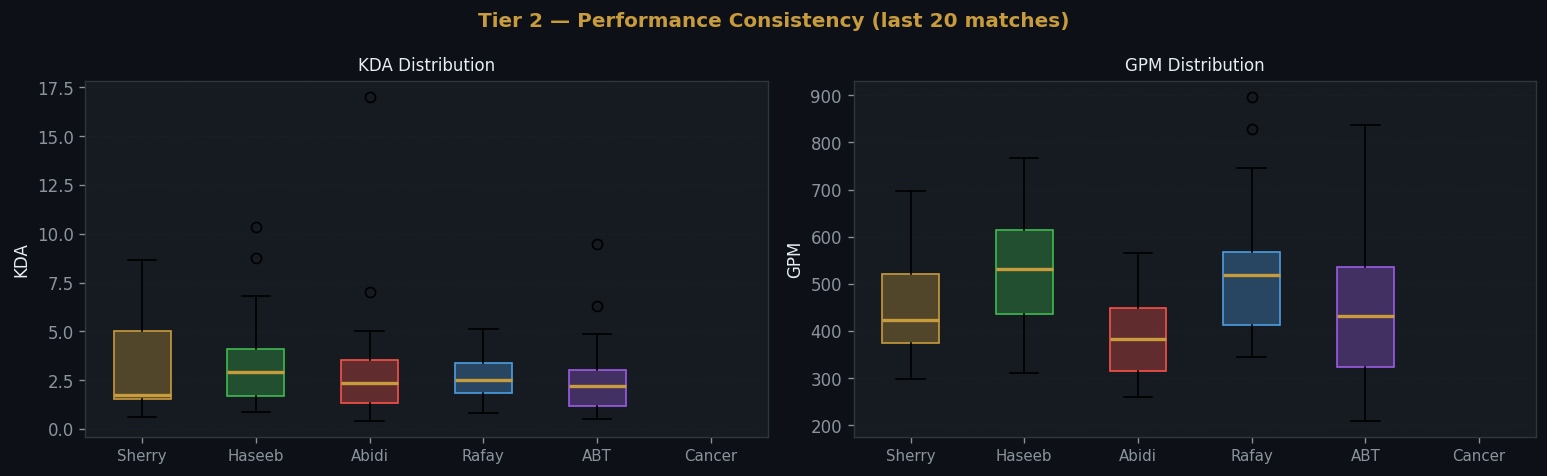

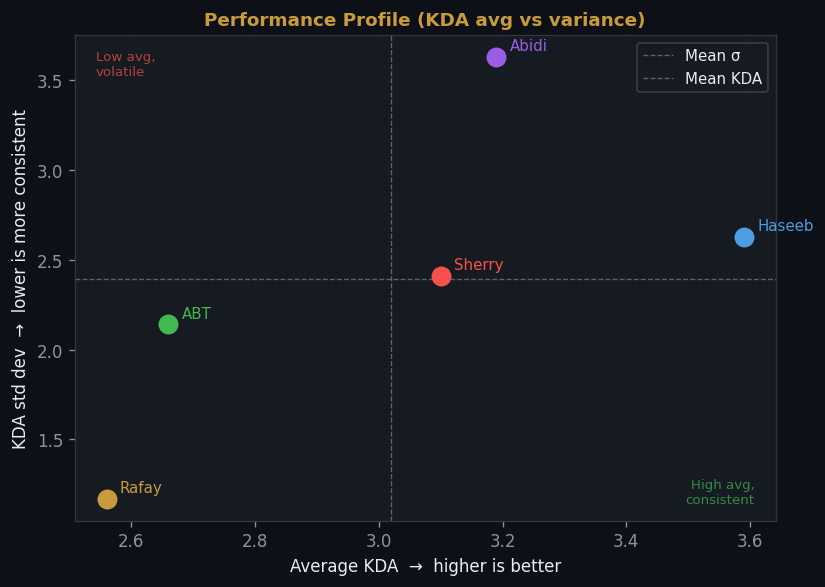

In [36]:
# Compute variance metrics for all players
cons_rows = []
for aid, d in D.items():
    ms = d['recent'][:20]
    if len(ms) < 2: continue
    kdas = [m['kda'] for m in ms]
    gpms = [m['gold_per_min'] for m in ms]
    dmgs = [m['dmg_per_min'] for m in ms]
    cons_rows.append({
        'Label':    d['label'],
        'Avg KDA':  round(sum(kdas)/len(kdas), 2),
        'KDA σ':    round(statistics.stdev(kdas), 2),
        'Avg GPM':  round(sum(gpms)/len(gpms), 0),
        'GPM σ':    round(statistics.stdev(gpms), 0),
        'DMG/m σ':  round(statistics.stdev(dmgs), 1),
    })

df_cons = pd.DataFrame(cons_rows).sort_values('KDA σ')
print('Consistency (lower σ = more consistent):')
print(df_cons.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('Tier 2 — Performance Consistency (last 20 matches)', color=GOLD, fontsize=12, fontweight='bold')

# KDA box plots per player
ax = axes[0]
kda_by_player = [[m['kda'] for m in D[f['account_id']]['recent'][:20]] for f in FRIENDS]
bp = ax.boxplot(kda_by_player, patch_artist=True, medianprops={'color': GOLD, 'linewidth': 2})
for patch, col in zip(bp['boxes'], PALETTE):
    patch.set_facecolor(col + '55'); patch.set_edgecolor(col)
ax.set_xticklabels([f['label'] for f in FRIENDS], fontsize=9)
ax.set_ylabel('KDA'); ax.set_title('KDA Distribution', fontsize=10); ax.grid(axis='y', alpha=0.3)

# GPM box plots per player
ax2 = axes[1]
gpm_by_player = [[m['gold_per_min'] for m in D[f['account_id']]['recent'][:20]] for f in FRIENDS]
bp2 = ax2.boxplot(gpm_by_player, patch_artist=True, medianprops={'color': GOLD, 'linewidth': 2})
for patch, col in zip(bp2['boxes'], PALETTE):
    patch.set_facecolor(col + '55'); patch.set_edgecolor(col)
ax2.set_xticklabels([f['label'] for f in FRIENDS], fontsize=9)
ax2.set_ylabel('GPM'); ax2.set_title('GPM Distribution', fontsize=10); ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('notebook_cache/t2_consistency.png', bbox_inches='tight', facecolor='#0d1117')
plt.show()

# Scatter: Avg KDA vs KDA σ — the 'performance profile' view
fig, ax = plt.subplots(figsize=(7, 5))
fig.patch.set_facecolor('#0d1117')
for i, row in df_cons.iterrows():
    col = PALETTE[list(df_cons.index).index(i) % len(PALETTE)]
    ax.scatter(row['Avg KDA'], row['KDA σ'], s=120, color=col, zorder=5)
    ax.annotate(row['Label'], (row['Avg KDA'], row['KDA σ']),
                textcoords='offset points', xytext=(8, 4), fontsize=9, color=col)

ax.axhline(df_cons['KDA σ'].mean(), color='#8b949e', linestyle='--', linewidth=0.8, alpha=0.6, label='Mean σ')
ax.axvline(df_cons['Avg KDA'].mean(), color='#8b949e', linestyle='--', linewidth=0.8, alpha=0.6, label='Mean KDA')
ax.set_xlabel('Average KDA  →  higher is better')
ax.set_ylabel('KDA std dev  →  lower is more consistent')
ax.set_title('Performance Profile (KDA avg vs variance)', color=GOLD, fontsize=11, fontweight='bold')
ax.legend(framealpha=0.2, fontsize=9); ax.grid(alpha=0.3)
# Annotate quadrants
ax.text(0.97, 0.03, 'High avg,\nconsistent', transform=ax.transAxes, ha='right', va='bottom', fontsize=8, color=GREEN, alpha=0.7)
ax.text(0.03, 0.97, 'Low avg,\nvolatile',    transform=ax.transAxes, ha='left',  va='top',    fontsize=8, color=RED,   alpha=0.7)
plt.tight_layout()
plt.savefig('notebook_cache/t2_performance_profile.png', bbox_inches='tight', facecolor='#0d1117')
plt.show()

## 13 · Differential Analysis — Marginal Win-Rate

Measures how each player's win-rate shifts relative to **their own career baseline** across three dimensions:
1. **With teammate** — Δ WR when queueing with a specific friend (≥5 games together, from `/peers`)
2. **By role** — Δ WR per lane role (last 20 matches, ≥2 games in role; small sample)
3. **By hero** — Δ WR on each hero vs baseline (career stats, ≥5 games on hero)

Results are saved to `data/diff_player_x_*.parquet`.
> Re-run §2 first if newly added friends (Cancer / Zain) are missing from `D`.

In [ ]:
# ── Baselines & lookup tables ─────────────────────────────────────────────────
baselines = {}
for aid, d in D.items():
    w, l = d['wl']['win'], d['wl']['lose']
    baselines[aid] = w / (w + l) * 100 if (w + l) else 50.0

label_map  = {aid: d['label'] for aid, d in D.items()}
all_labels = [label_map[aid] for aid in [f['account_id'] for f in FRIENDS] if aid in label_map]
Path('data').mkdir(exist_ok=True)

# ── 1 · Player × Player ───────────────────────────────────────────────────────
pp_rows = []
for i_aid, d in D.items():
    peer_map = {p['account_id']: p for p in d['peers']}
    base = baselines[i_aid]
    for j_aid in D:
        if i_aid == j_aid:
            continue
        p = peer_map.get(j_aid)
        if p and p.get('with_games', 0) >= 5:
            with_wr = p['with_win'] / p['with_games'] * 100
            pp_rows.append({
                'player':      label_map[i_aid],
                'with_player': label_map[j_aid],
                'baseline_wr': round(base, 2),
                'with_wr':     round(with_wr, 2),
                'delta':       round(with_wr - base, 2),
                'games':       p['with_games'],
            })

df_pp = pd.DataFrame(pp_rows)
df_pp.to_parquet('data/diff_player_x_player.parquet', index=False)

# ── 2 · Player × Role ─────────────────────────────────────────────────────────
# Uses DEEP (200-match cache from §2b) when available; falls back to last 20.
_ROLE_NAMES = {1: 'Carry', 2: 'Mid', 3: 'Offlane', 4: 'Jungle', 5: 'Support'}
_ROLE_ORDER = ['Carry', 'Mid', 'Offlane', 'Support', 'Jungle']

try:
    _deep_available = bool(DEEP)
except NameError:
    _deep_available = False

_src_label = f'{MATCH_LIMIT} matches (§2b cache)' if _deep_available else '20 matches (recentMatches)'
print(f'Role data source: {_src_label}')

role_rows = []
for aid, d in D.items():
    base    = baselines[aid]
    label   = label_map[aid]
    matches = DEEP.get(aid, []) if _deep_available else d['recent'][:20]
    buckets = {rn: {'g': 0, 'w': 0} for rn in _ROLE_NAMES.values()}
    for m in matches:
        rn = _ROLE_NAMES.get(m.get('lane_role'))
        if rn:
            buckets[rn]['g'] += 1
            if m['won']:
                buckets[rn]['w'] += 1
    for role, v in buckets.items():
        if v['g'] >= 3:
            role_wr = v['w'] / v['g'] * 100
            role_rows.append({
                'player':      label,
                'role':        role,
                'baseline_wr': round(base, 2),
                'role_wr':     round(role_wr, 2),
                'delta':       round(role_wr - base, 2),
                'games':       v['g'],
            })

df_pr = pd.DataFrame(role_rows)
df_pr.to_parquet('data/diff_player_x_role.parquet', index=False)

# ── 3 · Player × Hero ─────────────────────────────────────────────────────────
hero_rows = []
for aid, d in D.items():
    base  = baselines[aid]
    label = label_map[aid]
    for h in d['heroes']:
        if h['games'] < 5:
            continue
        hero_wr = h['win'] / h['games'] * 100
        hero_rows.append({
            'player':      label,
            'hero_id':     h['hero_id'],
            'hero':        HERO_NAMES.get(h['hero_id'], f'Hero {h["hero_id"]}'),
            'baseline_wr': round(base, 2),
            'hero_wr':     round(hero_wr, 2),
            'delta':       round(hero_wr - base, 2),
            'games':       h['games'],
        })

df_ph = pd.DataFrame(hero_rows)
df_ph.to_parquet('data/diff_player_x_hero.parquet', index=False)

print('Saved to data/:')
print(f'  diff_player_x_player.parquet  — {len(df_pp)} pairs (≥5 games together)')
print(f'  diff_player_x_role.parquet    — {len(df_pr)} entries (≥3 games in role)')
print(f'  diff_player_x_hero.parquet    — {len(df_ph)} hero entries (≥5 career games)')
print('\nBaseline win-rates:')
for aid in [f['account_id'] for f in FRIENDS]:
    if aid in baselines:
        print(f'  {label_map[aid]:8s}  {baselines[aid]:.1f}%')

DIV_CMAP  = sns.diverging_palette(10, 130, as_cmap=True)
_PALETTE7 = [GOLD, GREEN, RED, BLUE, PURPLE, ORANGE, '#e05d9b']

# ── Figure 1 · Player × Player heatmap ────────────────────────────────────────
if df_pp.empty:
    print('\n[Player×Player] No pairs with ≥5 games — re-run §2 after adding new friends.')
else:
    pp_pivot = df_pp.pivot_table(index='player', columns='with_player', values='delta')
    pp_pivot = pp_pivot.reindex(all_labels, axis=0).reindex(all_labels, axis=1)
    annot_pp = pp_pivot.map(lambda v: f'{v:+.1f}' if pd.notna(v) else '·')

    fig, ax = plt.subplots(figsize=(10, 7))
    fig.patch.set_facecolor('#0d1117')
    sns.heatmap(pp_pivot, ax=ax, cmap=DIV_CMAP, center=0, vmin=-20, vmax=20,
                annot=annot_pp, fmt='', linewidths=0.5, linecolor='#21262d',
                cbar_kws={'label': 'Δ Win Rate %', 'shrink': 0.7},
                annot_kws={'size': 11, 'fontweight': 'bold'})
    ax.set_title(
        'Player × Player — Δ WR vs career baseline when playing together\n'
        "(row-player's WR lift when queueing with column-player · ≥5 games)",
        color=GOLD, fontsize=11, fontweight='bold')
    ax.set_xlabel('Playing with →', fontsize=9)
    ax.set_ylabel('Player →', fontsize=9)
    plt.tight_layout()
    plt.savefig('notebook_cache/diff_player_x_player.png', bbox_inches='tight', facecolor='#0d1117')
    plt.show()

# ── Figure 2 · Player × Role heatmap ──────────────────────────────────────────
if df_pr.empty:
    print('\n[Player×Role] No role data — run §2b first or ensure ≥3 games per role.')
else:
    pr_pivot = df_pr.pivot_table(index='player', columns='role', values='delta')
    pr_pivot = pr_pivot.reindex(all_labels, axis=0).reindex(_ROLE_ORDER, axis=1)
    gm_pivot = df_pr.pivot_table(index='player', columns='role', values='games', aggfunc='sum')
    gm_pivot = gm_pivot.reindex(all_labels, axis=0).reindex(_ROLE_ORDER, axis=1)
    annot_pr = pr_pivot.map(lambda v: f'{v:+.0f}%' if pd.notna(v) else '—')

    fig, ax = plt.subplots(figsize=(9, max(4, len(all_labels) * 0.85)))
    fig.patch.set_facecolor('#0d1117')
    sns.heatmap(pr_pivot, ax=ax, cmap=DIV_CMAP, center=0, vmin=-35, vmax=35,
                annot=annot_pr, fmt='', linewidths=0.5, linecolor='#21262d',
                cbar_kws={'label': 'Δ Win Rate %', 'shrink': 0.7},
                annot_kws={'size': 10, 'fontweight': 'bold'})
    for i, player in enumerate(pr_pivot.index):
        for j, role in enumerate(pr_pivot.columns):
            try:
                g = gm_pivot.loc[player, role]
                if pd.notna(g) and int(g) > 0:
                    ax.text(j + 0.5, i + 0.82, f'{int(g)}g',
                            ha='center', va='center', fontsize=7, color='#8b949e')
            except KeyError:
                pass
    src_note = f'{MATCH_LIMIT}-match cache' if _deep_available else 'last 20 matches'
    ax.set_title(
        f'Player × Role — Δ WR vs career baseline  ({src_note} · ≥3 games per role)',
        color=GOLD, fontsize=11, fontweight='bold')
    ax.set_xlabel(''); ax.set_ylabel('')
    plt.tight_layout()
    plt.savefig('notebook_cache/diff_player_x_role.png', bbox_inches='tight', facecolor='#0d1117')
    plt.show()

# ── Figure 3 · Hero lift — top 5 heroes per player ────────────────────────────
if df_ph.empty:
    print('\n[Player×Hero] No hero data available.')
else:
    ncols     = 4
    nrows     = (len(all_labels) + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 4.2, nrows * 3.8))
    fig.patch.set_facecolor('#0d1117')
    fig.suptitle(
        'Hero Lift — Δ WR vs career baseline  (≥5 games on hero · top 5 shown)',
        color=GOLD, fontsize=12, fontweight='bold')
    axes_flat = axes.flatten() if hasattr(axes, 'flatten') else [axes]

    for idx, player in enumerate(all_labels):
        ax   = axes_flat[idx]
        col  = _PALETTE7[idx % len(_PALETTE7)]
        aid  = next((a for a, d in D.items() if d['label'] == player), None)
        base = baselines.get(aid, 50.0)
        sub  = df_ph[df_ph['player'] == player]

        if sub.empty:
            ax.text(0.5, 0.5, 'No data\n(re-run §2)', ha='center', va='center',
                    transform=ax.transAxes, color='#8b949e', fontsize=9)
            ax.set_title(player, fontsize=10, color=col)
            ax.axis('off')
            continue

        sub = sub.sort_values('delta', ascending=True).tail(5)
        bar_colors = [GREEN if v >= 0 else RED for v in sub['delta']]
        bars = ax.barh(sub['hero'], sub['delta'], color=bar_colors,
                       edgecolor='#21262d', height=0.6, alpha=0.85)
        ax.axvline(0, color='#8b949e', linewidth=0.8, linestyle='--', alpha=0.6)
        ax.set_facecolor('#161b22')

        for bar, val, g in zip(bars, sub['delta'], sub['games']):
            xpos = bar.get_width() + (0.5 if val >= 0 else -0.5)
            ha   = 'left' if val >= 0 else 'right'
            ax.text(xpos, bar.get_y() + bar.get_height() / 2,
                    f'{val:+.1f}%  {int(g)}g', va='center', fontsize=7.5, ha=ha, color='#e6edf3')

        ax.set_title(f'{player}  (base {base:.0f}%)', fontsize=10, color=col)
        ax.set_xlabel('Δ WR %', fontsize=8)
        ax.tick_params(labelsize=8)
        ax.grid(axis='x', alpha=0.3)

    for idx in range(len(all_labels), len(axes_flat)):
        axes_flat[idx].axis('off')

    plt.tight_layout()
    plt.savefig('notebook_cache/diff_hero_lift.png', bbox_inches='tight', facecolor='#0d1117')
    plt.show()